# (샘플) 이미지크롤링

In [6]:
from fastcore.all import *
import requests
import re
import json
from PIL import Image

In [7]:
def search_images_ddg(key,max_n=200):
    """Search for 'key' with DuckDuckGo and return a unique urls of 'max_n' images
       (Adopted from https://github.com/deepanprabhu/duckduckgo-images-api)
    """
    url        = 'https://duckduckgo.com/'
    params     = {'q':key}
    res        = requests.post(url,data=params)
    searchObj  = re.search(r'vqd=([\d-]+)\&',res.text)
    if not searchObj: print('Token Parsing Failed !'); return
    requestUrl = url + 'i.js'
    headers    = {'User-Agent': 'Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:71.0) Gecko/20100101 Firefox/71.0'}
    params     = (('l','us-en'),('o','json'),('q',key),('vqd',searchObj.group(1)),('f',',,,'),('p','1'),('v7exp','a'))
    urls       = []
    while True:
        try:
            res  = requests.get(requestUrl,headers=headers,params=params)
            data = json.loads(res.text)
            for obj in data['results']:
                urls.append(obj['image'])
                max_n = max_n - 1
                if max_n < 1: return L(set(urls))     # dedupe
            if 'next' not in data: return L(set(urls))
            requestUrl = url + data['next']
        except:
            pass
        
def download_images(dest, url_file=None, urls=None, max_pics=1000, n_workers=8, timeout=4, preserve_filename=False):
    "Download images listed in text file `url_file` to path `dest`, at most `max_pics`"
    if urls is None: urls = url_file.read_text().strip().split("\n")[:max_pics]
    dest = Path(dest)
    dest.mkdir(exist_ok=True)
    parallel(partial(_download_image_inner, dest, timeout=timeout, preserve_filename=preserve_filename),
             L(enumerate(urls)), n_workers=n_workers, threadpool=True)

def _download_image_inner(dest, inp, timeout=4, preserve_filename=False):
    i,url = inp
    url = url.split("?")[0]
    url_path = Path(url)
    suffix = url_path.suffix if url_path.suffix else '.jpg'
    name = _get_downloaded_image_filename(dest, url_path.stem, suffix) if preserve_filename else f"{i:08d}"
    try: download_url(url, dest/f"{name}{suffix}", show_progress=False, timeout=timeout)
    except Exception as e: f"Couldn't download {url}."

In [8]:
search_images_ddg('hynn',max_n=5)

(#5) ['https://lastfm.freetls.fastly.net/i/u/770x0/741dad37030af26991e237f21640622c.jpg','http://file.osen.co.kr/article/2019/04/04/201904041421779742_5ca5952d043a9_1024x.jpg','https://yt3.ggpht.com/a/AGF-l7_1jF579BUaWHBEpY95iZAb0WI2SC4vykeo3A=s900-c-k-c0xffffffff-no-rj-mo','https://kpopwiki.org/wp-content/uploads/2020/11/1593389807052.jpg','http://talkimg.imbc.com/TVianUpload/tvian/TViews/image/2020/03/21/GRMTjLNM9a88637203974033409433.jpg']

In [9]:
download_images('.',urls=search_images_ddg('hynn',max_n=5))

In [10]:
download_images?

Signature:
download_images(
    dest,
    url_file=None,
    urls=None,
    max_pics=1000,
    n_workers=8,
    timeout=4,
    preserve_filename=False,
)
Docstring: Download images listed in text file `url_file` to path `dest`, at most `max_pics`
File:      ~/Dropbox/01_yechan/_notebooks/<ipython-input-7-6ffd909c508d>
Type:      function


In [1]:
import requests
import re
import json
from PIL import Image

In [2]:
def search_images_ddg(key,max_n=200):
    """Search for 'key' with DuckDuckGo and return a unique urls of 'max_n' images
       (Adopted from https://github.com/deepanprabhu/duckduckgo-images-api)
    """
    url        = 'https://duckduckgo.com/'
    params     = {'q':key}
    res        = requests.post(url,data=params)
    searchObj  = re.search(r'vqd=([\d-]+)\&',res.text)
    if not searchObj: print('Token Parsing Failed !'); return
    requestUrl = url + 'i.js'
    headers    = {'User-Agent': 'Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:71.0) Gecko/20100101 Firefox/71.0'}
    params     = (('l','us-en'),('o','json'),('q',key),('vqd',searchObj.group(1)),('f',',,,'),('p','1'),('v7exp','a'))
    urls       = []
    while True:
        try:
            res  = requests.get(requestUrl,headers=headers,params=params)
            data = json.loads(res.text)
            for obj in data['results']:
                urls.append(obj['image'])
                max_n = max_n - 1
                if max_n < 1: return list(set(urls))     # dedupe
            if 'next' not in data: return list(set(urls))
            requestUrl = url + data['next']
        except:
            pass

In [3]:
hynn_lst = search_images_ddg('hynn',max_n=5)

In [4]:
hynn_lst[0]

'https://kpopwiki.org/wp-content/uploads/2020/11/1593389807052.jpg'

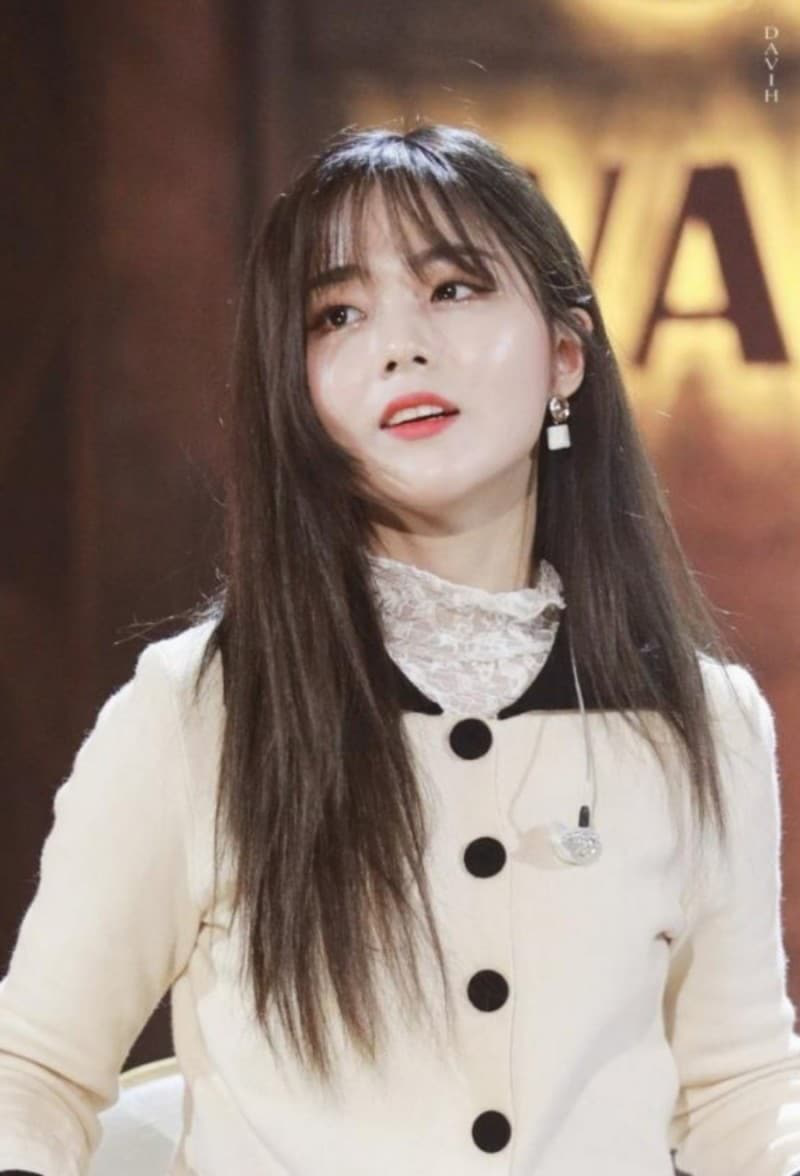

In [5]:
img=Image.open(Image.io.BytesIO(requests.get(hynn_lst[0]).content))
img